### What goes into Notebook 01:
* stratified train/validation split from the training set only
* first XGBoost multiclass run on 34-class
* evaluate with accuracy, weighted F1, macro F1, and per-class report
* save:
  * label encoder
  * model
  * feature column list
  * validation metrics
* only after that, run once on the merged holdout test set

### A good practical starting point for XGBoost is:
* `objective="multi:softprob"`
* `eval_metric="mlogloss"`
* `tree_method="hist"`
* `device="cuda"`
* `n_estimators` around 300 to 600
* `max_depth` around 6 to 10
* `learning_rate` around 0.05 to 0.1
* `subsample` around 0.8
* `colsample_bytree` around 0.8

Then we tune from there.

### Cell 1 -- Imports
This cell loads all libraries used by the notebook.

Improvements in this revision:
- Added imports for extra baselines (Random Forest, Logistic Regression) and threshold search utilities.

Expected inputs:
- None (library imports only).

Expected outputs:
- Imported modules available to later cells.

Tweakable variables:
- None in this cell.

In [1]:
from pathlib import Path
from collections import defaultdict
import itertools
import json
import random
import re

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost.core import XGBoostError

### Cell 2 -- Config
This cell defines all experiment settings used in training and evaluation.

Improvements in this revision:
- Added file-level split controls (no file leakage across train/validation).
- Added mixed-prior sampling controls with minority floors.
- Added stronger training knobs and gating knobs for RECON/WEB.
- Added engineered feature list to improve separation for weak groups.

Expected inputs:
- None (constants only).

Expected outputs:
- Global configuration variables consumed by later cells.

Tweakable variables:
- `VAL_FILE_SIZE`, `TRAIN_TOTAL_ROWS_BUDGET`, `VAL_TOTAL_ROWS_BUDGET`
- `TRAIN_MIN_ROWS_PER_CLASS`, `VAL_MIN_ROWS_PER_CLASS`
- `PRIOR_BLEND_ALPHA`
- `XGB_DEVICE`, `GATED_CLASSES`, `GATE_THRESHOLD_GRID`

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

TRAIN_MANIFEST_PATH = Path("artifacts/train_manifest.csv")
MODEL_DIR = Path("artifacts/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "label_8"
SOURCE_PATH_COL = "path"
VAL_FILE_SIZE = 0.20
CHUNKSIZE = 250_000
XGB_DEVICE = "cuda"

BASE_FEATURE_COLUMNS = [
    "Header_Length",
    "Protocol Type",
    "Time_To_Live",
    "Rate",
    "fin_flag_number",
    "syn_flag_number",
    "rst_flag_number",
    "psh_flag_number",
    "ack_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "rst_count",
    "HTTP",
    "HTTPS",
    "DNS",
    "Telnet",
    "SMTP",
    "SSH",
    "IRC",
    "TCP",
    "UDP",
    "DHCP",
    "ARP",
    "ICMP",
    "IGMP",
    "IPv",
    "LLC",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "IAT",
    "Number",
    "Variance",
]

ENGINEERED_FEATURE_COLUMNS = [
    "pkt_size_range",
    "flag_activity",
    "transport_ratio_tcp_udp",
    "service_ratio_dns_http",
    "rate_iat_interaction",
]

ALL_FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + ENGINEERED_FEATURE_COLUMNS

TRAIN_TOTAL_ROWS_BUDGET = 1_000_000
TRAIN_MIN_ROWS_PER_CLASS = 12_000
VAL_TOTAL_ROWS_BUDGET = 300_000
VAL_MIN_ROWS_PER_CLASS = 2_500
PRIOR_BLEND_ALPHA = 0.85

CUSTOM_DEPLOYMENT_PRIOR = None

GATED_CLASSES = ["RECON", "WEB"]
GATE_THRESHOLD_GRID = np.round(np.arange(0.35, 0.91, 0.05), 2)
MIN_GATED_PRECISION_TARGET = 0.60
GATE_PENALTY_WEIGHT = 0.02

### Cell 3 -- Manifest and Label Dictionaries
This cell loads the file manifest and builds class/id lookup mappings.

Improvements in this revision:
- Added manifest schema validation and class distribution display.
- Keeps mapping logic explicit for reproducibility in metrics and artifacts.

Expected inputs:
- `TRAIN_MANIFEST_PATH`, `TARGET_COL`, `SOURCE_PATH_COL`.

Expected outputs:
- `train_manifest`, `class_names`, `label_to_id`, `id_to_label`.

Tweakable variables:
- `TARGET_COL` if you want to train on a different label granularity.

In [3]:
train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)

required_manifest_cols = {SOURCE_PATH_COL, TARGET_COL}
missing_manifest_cols = required_manifest_cols.difference(train_manifest.columns)
if missing_manifest_cols:
    raise RuntimeError(f"Manifest is missing required columns: {sorted(missing_manifest_cols)}")

train_manifest = train_manifest.dropna(subset=[SOURCE_PATH_COL, TARGET_COL]).copy()
train_manifest[SOURCE_PATH_COL] = train_manifest[SOURCE_PATH_COL].astype(str)

class_names = sorted(train_manifest[TARGET_COL].unique())
label_to_id = {label: i for i, label in enumerate(class_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Number of classes:", len(class_names))
display(train_manifest[TARGET_COL].value_counts().rename("file_count").to_frame())

Number of classes: 8


,file_count
label_8,
DDOS,176
MIRAI,76
DOS,38
WEB,6
RECON,5
BENIGN,4
SPOOFING,3
BRUTEFORCE,1


### Cell 4 -- File-Aware Split and Mixed-Prior Sampler Helpers
This cell defines helper functions for splitting by file (group-aware), building mixed-prior class targets, and sampling rows without train/validation file leakage.

Improvements in this revision:
- Replaces row-level split with file-level split before sampling.
- Adds mixed strategy sampling: deployment-prior blend + minority floor.
- Adds targeted engineered features for better WEB/RECON separation.

Expected inputs:
- Manifest with one row per source file path and its group label.

Expected outputs:
- Helper functions used by the data build cell.

Tweakable variables:
- `PRIOR_BLEND_ALPHA`, budget and floor knobs, engineered feature definitions.

In [4]:
def add_targeted_features(df):
    out = df.copy()
    out["pkt_size_range"] = (out["Max"] - out["Min"]).astype("float32")
    out["flag_activity"] = (
        out["fin_flag_number"]
        + out["syn_flag_number"]
        + out["rst_flag_number"]
        + out["psh_flag_number"]
        + out["ack_flag_number"]
        + out["ece_flag_number"]
        + out["cwr_flag_number"]
    ).astype("float32")
    out["transport_ratio_tcp_udp"] = ((out["TCP"] + 1.0) / (out["UDP"] + 1.0)).astype("float32")
    out["service_ratio_dns_http"] = ((out["DNS"] + 1.0) / (out["HTTP"] + out["HTTPS"] + 1.0)).astype("float32")
    out["rate_iat_interaction"] = (out["Rate"] * out["IAT"]).astype("float32")
    return out


def split_manifest_by_file(
    manifest_df,
    source_col=SOURCE_PATH_COL,
    target_col=TARGET_COL,
    val_size=VAL_FILE_SIZE,
    seed=SEED,
):
    file_manifest = manifest_df[[source_col, target_col]].drop_duplicates(subset=[source_col]).copy()
    label_counts = file_manifest[target_col].value_counts()

    rare_mask = file_manifest[target_col].map(label_counts) < 2
    rare_files = file_manifest[rare_mask].copy()
    common_files = file_manifest[~rare_mask].copy()

    if len(common_files) == 0:
        raise RuntimeError("No classes have at least two files; cannot build validation split.")

    stratify_labels = common_files[target_col] if common_files[target_col].nunique() > 1 else None
    train_common, val_common = train_test_split(
        common_files,
        test_size=val_size,
        random_state=seed,
        stratify=stratify_labels,
    )

    train_files = pd.concat([train_common, rare_files], ignore_index=True)
    val_files = val_common.reset_index(drop=True)

    overlap = set(train_files[source_col]).intersection(set(val_files[source_col]))
    if overlap:
        raise RuntimeError("File leakage detected between train and validation manifests.")

    return train_files.reset_index(drop=True), val_files, rare_files.reset_index(drop=True)


def get_deployment_prior(
    manifest_df,
    class_order,
    target_col=TARGET_COL,
    alpha=PRIOR_BLEND_ALPHA,
    custom_prior=None,
):
    empirical = manifest_df[target_col].value_counts(normalize=True).reindex(class_order, fill_value=0.0)

    if custom_prior is not None:
        custom = pd.Series(custom_prior, dtype=float).reindex(class_order, fill_value=0.0)
        custom = custom.clip(lower=0)
        if custom.sum() <= 0:
            raise RuntimeError("CUSTOM_DEPLOYMENT_PRIOR must contain positive mass.")
        empirical = custom / custom.sum()

    uniform = pd.Series(1.0 / len(class_order), index=class_order)
    blended = alpha * empirical + (1.0 - alpha) * uniform
    return blended / blended.sum()


def build_class_row_targets(prior_series, total_budget, min_rows_per_class):
    raw = (prior_series * float(total_budget)).round().astype(int)
    return {label: max(int(min_rows_per_class), int(raw[label])) for label in prior_series.index}


def sample_rows_from_manifest(
    manifest_df,
    base_feature_columns,
    all_feature_columns,
    class_target_rows,
    source_col=SOURCE_PATH_COL,
    target_col=TARGET_COL,
    chunksize=CHUNKSIZE,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    counters = defaultdict(int)
    parts = []

    shuffled = manifest_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    for row in shuffled.itertuples(index=False):
        label = getattr(row, target_col)
        remaining = int(class_target_rows.get(label, 0) - counters[label])

        if remaining <= 0:
            continue

        path = Path(getattr(row, source_col))
        if not path.exists():
            continue

        for chunk in pd.read_csv(path, usecols=base_feature_columns, chunksize=chunksize):
            for col in base_feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan)
            chunk = add_targeted_features(chunk)
            chunk = chunk.dropna(subset=all_feature_columns)

            if len(chunk) == 0:
                continue

            take_n = min(remaining, len(chunk))
            if take_n < len(chunk):
                idx = rng.choice(len(chunk), size=take_n, replace=False)
                chunk = chunk.iloc[idx].copy()
            else:
                chunk = chunk.copy()

            chunk[target_col] = label
            chunk["source_file"] = path.name

            parts.append(chunk[all_feature_columns + [target_col, "source_file"]])

            counters[label] += len(chunk)
            remaining = int(class_target_rows.get(label, 0) - counters[label])
            if remaining <= 0:
                break

    if len(parts) == 0:
        raise RuntimeError("No rows were sampled. Check manifest paths/features.")

    sampled_df = pd.concat(parts, ignore_index=True)
    return sampled_df, dict(counters)

### Cell 5 -- Build File-Aware Sampled Train/Validation Frames
This cell applies the file-level split first, then samples rows independently inside train and validation file groups.

Improvements in this revision:
- Prevents leakage: no file appears in both train and validation.
- Uses mixed-prior sampling rather than near-uniform sampling.
- Saves file-level split manifests for reproducibility.

Expected inputs:
- `train_manifest` and helper functions from the previous cell.

Expected outputs:
- `train_sampled_df`, `val_sampled_df`
- `train_row_counts`, `val_row_counts`
- `train_files_manifest`, `val_files_manifest`
- Saved split CSVs in `MODEL_DIR`.

Tweakable variables:
- `TRAIN_TOTAL_ROWS_BUDGET`, `VAL_TOTAL_ROWS_BUDGET`
- `TRAIN_MIN_ROWS_PER_CLASS`, `VAL_MIN_ROWS_PER_CLASS`
- `PRIOR_BLEND_ALPHA` and optional `CUSTOM_DEPLOYMENT_PRIOR`

In [5]:
train_files_manifest, val_files_manifest, rare_files_manifest = split_manifest_by_file(
    train_manifest,
    source_col=SOURCE_PATH_COL,
    target_col=TARGET_COL,
    val_size=VAL_FILE_SIZE,
    seed=SEED,
 )

if len(val_files_manifest) == 0:
    raise RuntimeError("Validation manifest is empty after file-level split.")

deployment_prior = get_deployment_prior(
    train_manifest,
    class_order=class_names,
    target_col=TARGET_COL,
    alpha=PRIOR_BLEND_ALPHA,
    custom_prior=CUSTOM_DEPLOYMENT_PRIOR,
)

train_class_targets = build_class_row_targets(
    deployment_prior,
    total_budget=TRAIN_TOTAL_ROWS_BUDGET,
    min_rows_per_class=TRAIN_MIN_ROWS_PER_CLASS,
)
val_class_targets = build_class_row_targets(
    deployment_prior,
    total_budget=VAL_TOTAL_ROWS_BUDGET,
    min_rows_per_class=VAL_MIN_ROWS_PER_CLASS,
)

train_sampled_df, train_row_counts = sample_rows_from_manifest(
    train_files_manifest,
    base_feature_columns=BASE_FEATURE_COLUMNS,
    all_feature_columns=ALL_FEATURE_COLUMNS,
    class_target_rows=train_class_targets,
    source_col=SOURCE_PATH_COL,
    target_col=TARGET_COL,
    chunksize=CHUNKSIZE,
    seed=SEED,
)

val_sampled_df, val_row_counts = sample_rows_from_manifest(
    val_files_manifest,
    base_feature_columns=BASE_FEATURE_COLUMNS,
    all_feature_columns=ALL_FEATURE_COLUMNS,
    class_target_rows=val_class_targets,
    source_col=SOURCE_PATH_COL,
    target_col=TARGET_COL,
    chunksize=CHUNKSIZE,
    seed=SEED + 17,
)

shared_files = set(train_sampled_df["source_file"]).intersection(set(val_sampled_df["source_file"]))
if shared_files:
    raise RuntimeError(f"Detected leakage across splits: {len(shared_files)} overlapping files")

print("Train files:", len(train_files_manifest))
print("Validation files:", len(val_files_manifest))
print("Rare-class files forced into train:", len(rare_files_manifest))
print("Train sampled shape:", train_sampled_df.shape)
print("Validation sampled shape:", val_sampled_df.shape)

prior_table = pd.DataFrame({
    "deployment_prior": deployment_prior,
    "train_target_rows": pd.Series(train_class_targets),
    "val_target_rows": pd.Series(val_class_targets),
    "train_sampled_rows": pd.Series(train_row_counts),
    "val_sampled_rows": pd.Series(val_row_counts),
}).fillna(0)

display(prior_table.sort_values("deployment_prior", ascending=False))

train_files_manifest.to_csv(MODEL_DIR / "xgb_8class_train_files_manifest.csv", index=False)
val_files_manifest.to_csv(MODEL_DIR / "xgb_8class_val_files_manifest.csv", index=False)
print("Saved file-level split manifests.")

Train files: 247
Validation files: 62
Rare-class files forced into train: 1
Train sampled shape: (975726, 46)
Validation sampled shape: (288382, 46)


,deployment_prior,train_target_rows,val_target_rows,train_sampled_rows,val_sampled_rows
DDOS,0.502892,502892,150868,502892,150868.0
MIRAI,0.227811,227811,68343,227811,68343.0
DOS,0.123281,123281,36984,123281,36984.0
WEB,0.035255,35255,10576,19419,5409.0
RECON,0.032504,32504,9751,32504,9751.0
BENIGN,0.029753,29753,8926,29753,8926.0
SPOOFING,0.027002,27002,8101,27002,8101.0
BRUTEFORCE,0.021501,21501,6450,13064,0.0


Saved file-level split manifests.


### Cell 6 -- Build Modeling Matrices (No Row Split)
This cell converts sampled train/validation frames into model matrices and labels.

Improvements in this revision:
- Removes row-level `train_test_split` to preserve file-aware split protocol.
- Keeps label strings for later binary baseline and diagnostics.

Expected inputs:
- `train_sampled_df`, `val_sampled_df`, label dictionaries.

Expected outputs:
- `X_train`, `y_train`, `X_val`, `y_val`
- `y_train_label`, `y_val_label`
- Class-count sanity tables.

Tweakable variables:
- Feature set via `ALL_FEATURE_COLUMNS`.

In [6]:
train_sampled_df = train_sampled_df[train_sampled_df[TARGET_COL].isin(class_names)].copy()
val_sampled_df = val_sampled_df[val_sampled_df[TARGET_COL].isin(class_names)].copy()

X_train = train_sampled_df[ALL_FEATURE_COLUMNS].astype("float32")
y_train = train_sampled_df[TARGET_COL].map(label_to_id).astype("int32")
X_val = val_sampled_df[ALL_FEATURE_COLUMNS].astype("float32")
y_val = val_sampled_df[TARGET_COL].map(label_to_id).astype("int32")

y_train_label = train_sampled_df[TARGET_COL].astype(str).reset_index(drop=True)
y_val_label = val_sampled_df[TARGET_COL].astype(str).reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("Train class counts:")
display(y_train_label.value_counts().to_frame("rows"))

print("Validation class counts:")
display(y_val_label.value_counts().to_frame("rows"))

X_train shape: (975726, 44)
X_val shape: (288382, 44)
Train class counts:


,rows
label_8,
DDOS,502892
MIRAI,227811
DOS,123281
RECON,32504
BENIGN,29753
SPOOFING,27002
WEB,19419
BRUTEFORCE,13064


Validation class counts:


,rows
label_8,
DDOS,150868
MIRAI,68343
DOS,36984
RECON,9751
BENIGN,8926
SPOOFING,8101
WEB,5409


### Cell 7 -- Train XGBoost with Stronger Regularization and Early Stopping
This cell trains the multiclass XGBoost model with higher regularization and large estimator budget, then uses early stopping to pick effective complexity.

Improvements in this revision:
- Increased estimator budget with early stopping configured on the estimator.
- Reduced effective complexity (`max_depth`) and increased regularization (`reg_alpha`, `reg_lambda`, `gamma`, `min_child_weight`).
- Captures and reports best iteration.
- Uses an XGBoost 2.1+ compatible API pattern (no `early_stopping_rounds` passed to `fit`).

Expected inputs:
- `X_train`, `y_train`, `X_val`, `y_val`, and device config.

Expected outputs:
- Trained `model` and tracking variables `best_iteration`, `best_score`, `trained_device`.

Tweakable variables:
- `n_estimators`, `learning_rate`, `max_depth`, regularization knobs, `EARLY_STOPPING_ROUNDS`.

In [7]:
xgb_params = dict(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=8,
    gamma=0.2,
    subsample=0.75,
    colsample_bytree=0.70,
    reg_alpha=0.5,
    reg_lambda=6.0,
    max_delta_step=1,
    tree_method="hist",
    random_state=SEED,
    n_jobs=8,
)

EARLY_STOPPING_ROUNDS = 120

try:
    model = XGBClassifier(
        device=XGB_DEVICE,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        **xgb_params,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100,
    )
    trained_device = XGB_DEVICE
    print(f"Training completed (requested device='{XGB_DEVICE}').")
except XGBoostError as exc:
    error_text = str(exc).lower()
    is_cuda_error = ("cuda" in error_text) or ("array_interface.cu" in error_text)

    if str(XGB_DEVICE).lower() != "cuda" or not is_cuda_error:
        raise

    print("CUDA training failed. Falling back to CPU.")
    print(exc)

    model = XGBClassifier(
        device="cpu",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        **xgb_params,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100,
    )
    trained_device = "cpu"
    print("Training completed on device='cpu'.")

best_iteration = int(getattr(model, "best_iteration", model.n_estimators - 1))
best_score = getattr(model, "best_score", None)

print("Best iteration:", best_iteration)
print("Best score:", best_score)
print("Trained device:", trained_device)

/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:13:11] WARNING: /workspace/src/context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:13:11] WARNING: /workspace/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[0]	validation_0-mlogloss:2.04041	validation_1-mlogloss:2.04143
[100]	validation_0-mlogloss:0.22725	validation_1-mlogloss:0.54045
[200]	validation_0-mlogloss:0.11860	validation_1-mlogloss:0.60504
[236]	validation_0-mlogloss:0.11295	validation_1-mlogloss:0.67044
Training completed (requested device='cuda').
Best iteration: 117
Best score: 0.5343552035805467
Trained device: cuda


### Cell 8 -- Validation Metrics and Class-Specific Probability Gating
This cell evaluates raw validation predictions and then tunes class-specific probability gates for over-firing classes (RECON, WEB).

Improvements in this revision:
- Adds post-model threshold tuning for targeted precision fixes.
- Keeps both raw and gated validation metrics for transparent comparison.

Expected inputs:
- Trained `model`, validation matrices, class mappings, gating config.

Expected outputs:
- Raw and gated validation metrics/reports.
- `best_gate_id_thresholds` and `best_gate_thresholds` for holdout-time inference.

Tweakable variables:
- `GATED_CLASSES`, `GATE_THRESHOLD_GRID`, `MIN_GATED_PRECISION_TARGET`, `GATE_PENALTY_WEIGHT`.

In [8]:
def apply_class_probability_gates(probabilities, pred_ids, class_thresholds):
    if not class_thresholds:
        return pred_ids.copy()

    gated = pred_ids.copy()
    rank_idx = np.argsort(-probabilities, axis=1)

    for i in range(len(gated)):
        top_cls = int(gated[i])
        if top_cls not in class_thresholds:
            continue

        if probabilities[i, top_cls] >= class_thresholds[top_cls]:
            continue

        replacement = top_cls
        for candidate in rank_idx[i]:
            candidate = int(candidate)
            if candidate == top_cls:
                continue
            if candidate in class_thresholds and probabilities[i, candidate] < class_thresholds[candidate]:
                continue
            replacement = candidate
            break

        gated[i] = replacement

    return gated


def score_multiclass_predictions(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    weighted = f1_score(y_true, y_pred, average="weighted")

    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(len(class_names))),
            target_names=[id_to_label[i] for i in range(len(class_names))],
            output_dict=True,
            zero_division=0,
        )
    ).T

    return acc, macro, weighted, report


val_proba = model.predict_proba(X_val)
val_pred_raw = np.argmax(val_proba, axis=1).astype(np.int32)

val_acc_raw, val_f1_macro_raw, val_f1_weighted_raw, report_df_raw = score_multiclass_predictions(y_val, val_pred_raw)

best_gate_id_thresholds = {}
best_gate_thresholds = {}

gate_class_ids = [label_to_id[name] for name in GATED_CLASSES if name in label_to_id]
if gate_class_ids:
    best_objective = -np.inf
    best_payload = None

    for threshold_tuple in itertools.product(GATE_THRESHOLD_GRID, repeat=len(gate_class_ids)):
        gate_cfg = {cls_id: float(thr) for cls_id, thr in zip(gate_class_ids, threshold_tuple)}
        val_pred_tmp = apply_class_probability_gates(val_proba, val_pred_raw, gate_cfg)
        acc_tmp, macro_tmp, weighted_tmp, report_tmp = score_multiclass_predictions(y_val, val_pred_tmp)

        precision_penalty = 0.0
        for cls_id in gate_class_ids:
            cls_name = id_to_label[cls_id]
            if cls_name in report_tmp.index:
                cls_precision = float(report_tmp.loc[cls_name, "precision"])
                precision_penalty += max(0.0, MIN_GATED_PRECISION_TARGET - cls_precision)

        objective = macro_tmp - (GATE_PENALTY_WEIGHT * precision_penalty)

        if objective > best_objective:
            best_objective = objective
            best_payload = (gate_cfg, acc_tmp, macro_tmp, weighted_tmp, report_tmp, val_pred_tmp)

    best_gate_id_thresholds, val_acc_gated, val_f1_macro_gated, val_f1_weighted_gated, report_df_gated, val_pred_gated = best_payload
    best_gate_thresholds = {id_to_label[k]: float(v) for k, v in best_gate_id_thresholds.items()}
else:
    val_pred_gated = val_pred_raw.copy()
    val_acc_gated = val_acc_raw
    val_f1_macro_gated = val_f1_macro_raw
    val_f1_weighted_gated = val_f1_weighted_raw
    report_df_gated = report_df_raw.copy()

print("Validation (raw) accuracy:", val_acc_raw)
print("Validation (raw) macro F1:", val_f1_macro_raw)
print("Validation (raw) weighted F1:", val_f1_weighted_raw)

print("Validation (gated) accuracy:", val_acc_gated)
print("Validation (gated) macro F1:", val_f1_macro_gated)
print("Validation (gated) weighted F1:", val_f1_weighted_gated)
print("Chosen class gates:", best_gate_thresholds)

report_df = report_df_gated.copy()

comparison_df = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "raw": [val_acc_raw, val_f1_macro_raw, val_f1_weighted_raw],
    "gated": [val_acc_gated, val_f1_macro_gated, val_f1_weighted_gated],
})
display(comparison_df)

display(report_df_gated)

Validation (raw) accuracy: 0.828612742820287
Validation (raw) macro F1: 0.533630220786409
Validation (raw) weighted F1: 0.7803940054546642
Validation (gated) accuracy: 0.8279677649783967
Validation (gated) macro F1: 0.5347998161821627
Validation (gated) weighted F1: 0.7807579086519101
Chosen class gates: {'RECON': 0.35, 'WEB': 0.35}


,metric,raw,gated
0,accuracy,0.828613,0.827968
1,macro_f1,0.533630,0.534800
2,weighted_f1,0.780394,0.780758


,precision,recall,f1-score,support
BENIGN,0.531481,0.863433,0.657959,8926.000000
BRUTEFORCE,0.000000,0.000000,0.000000,0.000000
DDOS,0.811748,0.993319,0.893401,150868.000000
DOS,0.637956,0.060080,0.109818,36984.000000
MIRAI,0.976435,0.996152,0.986195,68343.000000
RECON,0.770697,0.638704,0.698520,9751.000000
SPOOFING,0.790116,0.303913,0.438977,8101.000000
WEB,0.622222,0.408948,0.493530,5409.000000
accuracy,0.827968,0.827968,0.827968,0.827968
macro avg,0.642582,0.533068,0.534800,288382.000000


### Cell 9 -- Save Improved Model and Metadata
This cell saves the improved XGBoost artifacts and validation reports.

Improvements in this revision:
- Stores best-iteration and gating metadata.
- Saves both raw and gated validation per-class reports.

Expected inputs:
- Trained model, feature list, mapping dictionaries, validation metrics and gate config.

Expected outputs:
- Model file and metadata JSON under `MODEL_DIR`.
- Validation per-class CSVs (`raw` and `gated`).

Tweakable variables:
- Output filenames if you want to version artifacts differently.

In [9]:
model_filename = "xgb_8class_improved.joblib"
metadata_filename = "xgb_8class_improved_metadata.json"

joblib.dump(model, MODEL_DIR / model_filename)

metadata = {
    "feature_columns_base": BASE_FEATURE_COLUMNS,
    "feature_columns_engineered": ENGINEERED_FEATURE_COLUMNS,
    "feature_columns_all": ALL_FEATURE_COLUMNS,
    "target_col": TARGET_COL,
    "class_names": class_names,
    "label_to_id": label_to_id,
    "seed": SEED,
    "split_protocol": "file_aware_group_split",
    "val_file_size": VAL_FILE_SIZE,
    "sampling": {
        "train_total_rows_budget": TRAIN_TOTAL_ROWS_BUDGET,
        "train_min_rows_per_class": TRAIN_MIN_ROWS_PER_CLASS,
        "val_total_rows_budget": VAL_TOTAL_ROWS_BUDGET,
        "val_min_rows_per_class": VAL_MIN_ROWS_PER_CLASS,
        "prior_blend_alpha": PRIOR_BLEND_ALPHA,
        "custom_deployment_prior": CUSTOM_DEPLOYMENT_PRIOR,
    },
    "training_params": xgb_params,
    "trained_device": trained_device,
    "best_iteration": int(best_iteration),
    "best_score": None if best_score is None else float(best_score),
    "validation_metrics_raw": {
        "accuracy": float(val_acc_raw),
        "macro_f1": float(val_f1_macro_raw),
        "weighted_f1": float(val_f1_weighted_raw),
    },
    "validation_metrics_gated": {
        "accuracy": float(val_acc_gated),
        "macro_f1": float(val_f1_macro_gated),
        "weighted_f1": float(val_f1_weighted_gated),
    },
    "gating": {
        "classes": GATED_CLASSES,
        "thresholds": best_gate_thresholds,
        "precision_target": MIN_GATED_PRECISION_TARGET,
        "penalty_weight": GATE_PENALTY_WEIGHT,
    },
}

with open(MODEL_DIR / metadata_filename, "w") as f:
    json.dump(metadata, f, indent=2)

report_df_raw.to_csv(MODEL_DIR / "xgb_8class_validation_per_class_raw.csv")
report_df_gated.to_csv(MODEL_DIR / "xgb_8class_validation_per_class_gated.csv")

print("Saved model:", MODEL_DIR / model_filename)
print("Saved metadata:", MODEL_DIR / metadata_filename)
print("Saved validation reports (raw and gated).")

Saved model: artifacts/models/xgb_8class_improved.joblib
Saved metadata: artifacts/models/xgb_8class_improved_metadata.json
Saved validation reports (raw and gated).


### Cell 10 -- Label Canonicalization and Grouping Variants
This cell standardizes raw labels and provides both the legacy 8-group mapping and a refined mapping for weak groups.

Improvements in this revision:
- Keeps compatibility with the legacy 8-class grouped label (`label_8`).
- Adds optional refined mapping (`refined_10`) that splits WEB and RECON into more specific groups for diagnostics.

Expected inputs:
- Raw label strings from CSV `Label` column.

Expected outputs:
- Canonicalized labels and mapping helper functions used in test-time chunk iteration.

Tweakable variables:
- `GROUPING_VERSION` (`legacy_8` or `refined_10`)
- Membership rules inside `map_label_to_group_refined`.

In [10]:
GROUPING_VERSION = "legacy_8"


def canonicalize_label(raw_label):
    if pd.isna(raw_label):
        return np.nan

    s = str(raw_label).strip()
    if s == "" or s.upper() == "NAN":
        return np.nan

    s = s.replace(".pcap.csv", "").replace(".csv", "").replace(".pcap", "")

    if re.fullmatch(r"BenignTraffic\d*", s, flags=re.IGNORECASE):
        return "BENIGN"
    if s.lower() == "benign_final":
        return "BENIGN"

    s = s.upper()
    s = s.replace("-", "_").replace(" ", "_")
    s = re.sub(r"__+", "_", s).strip("_")

    alias_map = {
        "BENIGNTRAFFIC": "BENIGN",
        "BENIGN_FINAL": "BENIGN",
        "BACKDOOR_MALWARE": "BACKDOOR_MALWARE",
        "BROWSERHIJACKING": "BROWSERHIJACKING",
        "COMMANDINJECTION": "COMMANDINJECTION",
        "SQLINJECTION": "SQLINJECTION",
        "UPLOADING_ATTACK": "UPLOADING_ATTACK",
        "XSS": "XSS",
        "MITM_ARPSPOOFING": "MITM_ARPSPOOFING",
        "DNS_SPOOFING": "DNS_SPOOFING",
        "DICTIONARYBRUTEFORCE": "DICTIONARYBRUTEFORCE",
        "RECON_HOSTDISCOVERY": "RECON_HOSTDISCOVERY",
        "RECON_OSSCAN": "RECON_OSSCAN",
        "RECON_PINGSWEEP": "RECON_PINGSWEEP",
        "RECON_PORTSCAN": "RECON_PORTSCAN",
        "VULNERABILITYSCAN": "VULNERABILITYSCAN",
        "MIRAI_GREETH_FLOOD": "MIRAI_GREETH_FLOOD",
        "MIRAI_GREIP_FLOOD": "MIRAI_GREIP_FLOOD",
        "MIRAI_UDPPLAIN": "MIRAI_UDPPLAIN",
    }

    return alias_map.get(s, s)


def map_label_to_group_legacy(label_34):
    if pd.isna(label_34):
        return np.nan
    if label_34 == "BENIGN":
        return "BENIGN"
    if label_34.startswith("DDOS_"):
        return "DDOS"
    if label_34.startswith("DOS_"):
        return "DOS"
    if label_34.startswith("RECON_") or label_34 == "VULNERABILITYSCAN":
        return "RECON"
    if label_34.startswith("MIRAI_"):
        return "MIRAI"
    if label_34 in {"DNS_SPOOFING", "MITM_ARPSPOOFING"}:
        return "SPOOFING"
    if label_34 == "DICTIONARYBRUTEFORCE":
        return "BRUTEFORCE"
    if label_34 in {
        "BACKDOOR_MALWARE",
        "BROWSERHIJACKING",
        "COMMANDINJECTION",
        "SQLINJECTION",
        "UPLOADING_ATTACK",
        "XSS",
    }:
        return "WEB"
    return "UNKNOWN"


def map_label_to_group_refined(label_34):
    if pd.isna(label_34):
        return np.nan
    if label_34 == "BENIGN":
        return "BENIGN"
    if label_34.startswith("DDOS_"):
        return "DDOS"
    if label_34.startswith("DOS_"):
        return "DOS"

    if label_34 in {"RECON_HOSTDISCOVERY", "RECON_PINGSWEEP"}:
        return "RECON_DISCOVERY"
    if label_34 in {"RECON_OSSCAN", "RECON_PORTSCAN", "VULNERABILITYSCAN"}:
        return "RECON_SCAN"

    if label_34.startswith("MIRAI_"):
        return "MIRAI"
    if label_34 in {"DNS_SPOOFING", "MITM_ARPSPOOFING"}:
        return "SPOOFING"
    if label_34 == "DICTIONARYBRUTEFORCE":
        return "BRUTEFORCE"

    if label_34 in {"COMMANDINJECTION", "SQLINJECTION", "UPLOADING_ATTACK", "XSS"}:
        return "WEB_INJECTION"
    if label_34 in {"BACKDOOR_MALWARE", "BROWSERHIJACKING"}:
        return "WEB_ABUSE"

    return "UNKNOWN"


def map_label_to_group(label_34, version=GROUPING_VERSION):
    if version == "refined_10":
        return map_label_to_group_refined(label_34)
    return map_label_to_group_legacy(label_34)


def map_label_to_binary(label_34):
    if pd.isna(label_34):
        return np.nan
    return "BENIGN" if label_34 == "BENIGN" else "MALICIOUS"

### Cell 11 -- Test Chunk Iterator with Feature Engineering and Group Diagnostics
This cell creates a memory-safe iterator for holdout CSV files and applies the same feature engineering as training.

Improvements in this revision:
- Uses `ALL_FEATURE_COLUMNS` (base + engineered) for consistency.
- Emits both legacy and refined grouped labels for diagnostics.

Expected inputs:
- Holdout files (`Merged*.csv`) and mapping helpers.

Expected outputs:
- Iterator yielding cleaned chunks with model features and label variants.

Tweakable variables:
- `TEST_ROOT`, `chunksize`, and `GROUPING_VERSION`.

In [11]:
TEST_ROOT = Path("../data/CIC_IOT_Dataset_2023")
test_files = sorted(TEST_ROOT.glob("Merged*.csv"))

print("TEST_ROOT:", TEST_ROOT.resolve())
print("Number of test files found:", len(test_files))
print("First 3 test files:", test_files[:3])

if len(test_files) == 0:
    raise RuntimeError("No test files found. Check TEST_ROOT.")


def iter_test_chunks(
    test_files,
    base_feature_columns,
    all_feature_columns,
    chunksize=250_000,
    grouping_version=GROUPING_VERSION,
):
    usecols = base_feature_columns + ["Label"]

    for path in test_files:
        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
            for col in base_feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan)
            chunk = add_targeted_features(chunk)
            chunk = chunk.dropna(subset=all_feature_columns)

            if len(chunk) == 0:
                continue

            chunk["label_raw"] = chunk["Label"]
            chunk["label_34"] = chunk["label_raw"].map(canonicalize_label)
            chunk["label_8_legacy"] = chunk["label_34"].map(map_label_to_group_legacy)
            chunk["label_8_refined"] = chunk["label_34"].map(map_label_to_group_refined)
            chunk[TARGET_COL] = chunk["label_34"].map(lambda x: map_label_to_group(x, version=grouping_version))
            chunk["label_bin"] = chunk["label_34"].map(map_label_to_binary)
            chunk["source_file"] = path.name

            yield chunk[
                all_feature_columns
                + ["label_raw", "label_34", "label_8_legacy", "label_8_refined", "label_bin", "source_file", TARGET_COL]
            ]

TEST_ROOT: /home/jacob/workspace/csusb/cic_iot_2023_analysis/data/CIC_IOT_Dataset_2023
Number of test files found: 63
First 3 test files: [PosixPath('../data/CIC_IOT_Dataset_2023/Merged01.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged02.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged03.csv')]


### Cell 12 -- Holdout Evaluation (Raw vs Gated)
This cell evaluates holdout chunks incrementally and reports both raw multiclass predictions and gated predictions.

Improvements in this revision:
- Applies tuned RECON/WEB gates at inference time.
- Reports side-by-side holdout metrics for raw vs gated outputs.

Expected inputs:
- Trained model, holdout iterator, class mappings, gate thresholds.

Expected outputs:
- Raw and gated confusion matrices + per-class tables.

Tweakable variables:
- Gating thresholds from Cell 8 and holdout chunk size.

In [12]:
def metrics_from_confusion_matrix(cm):
    total = cm.sum()
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp, dtype=float),
        where=(precision + recall) != 0,
    )

    accuracy = float(tp.sum() / total) if total > 0 else np.nan
    macro_f1 = float(np.mean(f1)) if len(f1) > 0 else np.nan
    weighted_f1 = float(np.average(f1, weights=support)) if support.sum() > 0 else np.nan

    per_class = pd.DataFrame({
        "label": [id_to_label[i] for i in range(len(class_names))],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

    return accuracy, macro_f1, weighted_f1, per_class


cm_raw = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
cm_gated = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
dropped_missing = 0
seen_rows = 0

for chunk in iter_test_chunks(
    test_files,
    base_feature_columns=BASE_FEATURE_COLUMNS,
    all_feature_columns=ALL_FEATURE_COLUMNS,
    chunksize=CHUNKSIZE,
    grouping_version=GROUPING_VERSION,
):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    dropped_missing += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[ALL_FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)

    pred_proba = model.predict_proba(X_chunk)
    y_pred_raw = np.argmax(pred_proba, axis=1).astype(np.int32)
    y_pred_gated = apply_class_probability_gates(pred_proba, y_pred_raw, best_gate_id_thresholds).astype(np.int32)

    np.add.at(cm_raw, (y_true, y_pred_raw), 1)
    np.add.at(cm_gated, (y_true, y_pred_gated), 1)
    seen_rows += len(chunk)

print("Evaluated test rows:", seen_rows)
print("Dropped unlabeled/invalid test rows:", dropped_missing)

test_acc_raw, test_macro_f1_raw, test_weighted_f1_raw, test_per_class_raw = metrics_from_confusion_matrix(cm_raw)
test_acc_gated, test_macro_f1_gated, test_weighted_f1_gated, test_per_class_gated = metrics_from_confusion_matrix(cm_gated)

print("Holdout RAW accuracy:", test_acc_raw)
print("Holdout RAW macro F1:", test_macro_f1_raw)
print("Holdout RAW weighted F1:", test_weighted_f1_raw)

print("Holdout GATED accuracy:", test_acc_gated)
print("Holdout GATED macro F1:", test_macro_f1_gated)
print("Holdout GATED weighted F1:", test_weighted_f1_gated)

holdout_compare = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "raw": [test_acc_raw, test_macro_f1_raw, test_weighted_f1_raw],
    "gated": [test_acc_gated, test_macro_f1_gated, test_weighted_f1_gated],
})
display(holdout_compare)

print("Gated holdout per-class results:")
display(test_per_class_gated.sort_values("support", ascending=False))

cm = cm_gated.copy()
test_acc = test_acc_gated
test_macro_f1 = test_macro_f1_gated
test_weighted_f1 = test_weighted_f1_gated
test_per_class = test_per_class_gated.copy()

Evaluated test rows: 45018243
Dropped unlabeled/invalid test rows: 0
Holdout RAW accuracy: 0.8024587943158954
Holdout RAW macro F1: 0.5065602160460954
Holdout RAW weighted F1: 0.7575107028051474
Holdout GATED accuracy: 0.803580894971845
Holdout GATED macro F1: 0.5069036122580141
Holdout GATED weighted F1: 0.7584060456938974


,metric,raw,gated
0,accuracy,0.802459,0.803581
1,macro_f1,0.506560,0.506904
2,weighted_f1,0.757511,0.758406


Gated holdout per-class results:


,label,precision,recall,f1,support
2,DDOS,0.823645,0.958007,0.885760,32535697
3,DOS,0.725986,0.137578,0.231320,7746340
4,MIRAI,0.698922,0.998038,0.822118,2521551
0,BENIGN,0.754080,0.802236,0.777413,1051313
5,RECON,0.702810,0.666861,0.684364,661108
6,SPOOFING,0.747191,0.268434,0.394971,465914
7,WEB,0.074407,0.368476,0.123812,23798
1,BRUTEFORCE,0.078992,0.475323,0.135471,12522


### Cell 13 -- Save Holdout Raw/Gated Artifacts
This cell writes holdout metrics, confusion matrices, and per-class reports for both raw and gated predictions.

Improvements in this revision:
- Persists raw-vs-gated outputs separately and keeps gated outputs as default compatibility files.

Expected inputs:
- `cm_raw`, `cm_gated`, per-class tables, and aggregate metrics from the previous cell.

Expected outputs:
- JSON metrics and CSV artifacts in `MODEL_DIR`.

Tweakable variables:
- Output filename conventions if you want alternate versioning.

In [13]:
labels = [id_to_label[i] for i in range(len(class_names))]

test_per_class_raw.to_csv(MODEL_DIR / "xgb_8class_test_per_class_raw.csv", index=False)
test_per_class_gated.to_csv(MODEL_DIR / "xgb_8class_test_per_class_gated.csv", index=False)

# Compatibility outputs (default to gated behavior).
test_per_class_gated.to_csv(MODEL_DIR / "xgb_8class_test_per_class.csv", index=False)

cm_raw_df = pd.DataFrame(cm_raw, index=labels, columns=labels)
cm_gated_df = pd.DataFrame(cm_gated, index=labels, columns=labels)
cm_raw_df.to_csv(MODEL_DIR / "xgb_8class_test_confusion_matrix_raw.csv")
cm_gated_df.to_csv(MODEL_DIR / "xgb_8class_test_confusion_matrix_gated.csv")
cm_gated_df.to_csv(MODEL_DIR / "xgb_8class_test_confusion_matrix.csv")

test_metrics = {
    "raw": {
        "accuracy": float(test_acc_raw),
        "macro_f1": float(test_macro_f1_raw),
        "weighted_f1": float(test_weighted_f1_raw),
    },
    "gated": {
        "accuracy": float(test_acc_gated),
        "macro_f1": float(test_macro_f1_gated),
        "weighted_f1": float(test_weighted_f1_gated),
    },
    "evaluated_test_rows": int(seen_rows),
    "dropped_unlabeled_or_invalid_rows": int(dropped_missing),
    "gating_thresholds": best_gate_thresholds,
}

with open(MODEL_DIR / "xgb_8class_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved holdout metrics, per-class reports, and confusion matrices (raw and gated).")

Saved holdout metrics, per-class reports, and confusion matrices (raw and gated).


### Cell 14 -- Feature Importance (Improved Model)
This cell extracts gain-based feature importance from the trained XGBoost model.

Improvements in this revision:
- Uses the full feature list (base + engineered) for readable feature mapping.

Expected inputs:
- Trained `model` and `ALL_FEATURE_COLUMNS`.

Expected outputs:
- Top-importance table, bar chart, and saved CSV file.

Tweakable variables:
- `importance_type` and top-k value for plotting.

,feature,gain
0,Tot sum,4050.117188
1,Tot size,3678.348145
2,AVG,3666.669922
3,Number,1770.772095
4,TCP,1116.424561
5,transport_ratio_tcp_udp,964.425171
6,rst_count,659.940430
7,HTTPS,621.986084
8,ack_count,588.872620
9,service_ratio_dns_http,304.239685


Saved feature importance to artifacts/models/xgb_8class_feature_importance_gain.csv


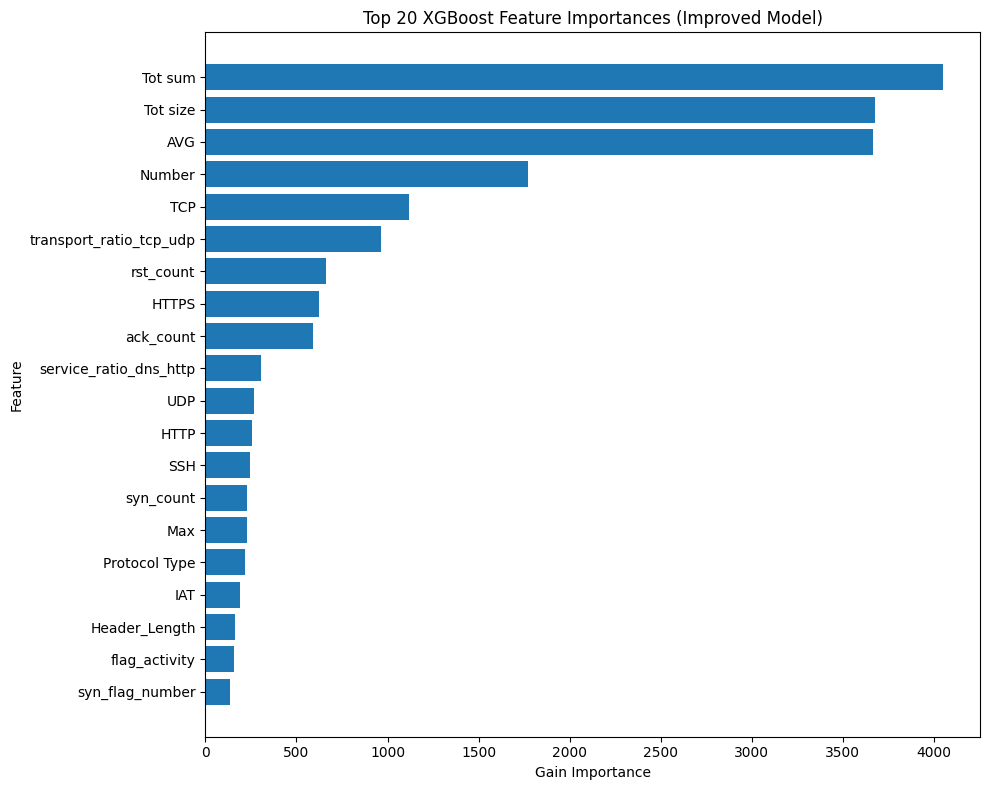

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

booster = model.get_booster()
score = booster.get_score(importance_type="gain")

if not score:
    raise RuntimeError("The model returned no feature importances.")

importance_df = pd.DataFrame({
    "feature": list(score.keys()),
    "gain": list(score.values()),
})

feature_map = {f"f{i}": col for i, col in enumerate(ALL_FEATURE_COLUMNS)}
importance_df["feature"] = importance_df["feature"].map(feature_map).fillna(importance_df["feature"])
importance_df = importance_df.sort_values("gain", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

importance_path = MODEL_DIR / "xgb_8class_feature_importance_gain.csv"
importance_df.to_csv(importance_path, index=False)
print(f"Saved feature importance to {importance_path}")

top_k = importance_df.head(20).sort_values("gain")
plt.figure(figsize=(10, 8))
plt.barh(top_k["feature"], top_k["gain"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances (Improved Model)")
plt.tight_layout()
plt.show()

### Cell 15 -- Validation vs Holdout Comparison
This cell compares per-class metrics between validation and holdout for both raw and gated outputs.

Improvements in this revision:
- Adds explicit drift checks between validation and holdout after gating.

Expected inputs:
- Validation report tables and saved holdout reports.

Expected outputs:
- Comparison tables and support-vs-F1 diagnostic plot.

Tweakable variables:
- Which report variant to treat as primary (`raw` vs `gated`).

Classes sorted by gated holdout F1:


,label,precision,recall,f1,support
7,WEB,0.074407,0.368476,0.123812,23798
1,BRUTEFORCE,0.078992,0.475323,0.135471,12522
3,DOS,0.725986,0.137578,0.231320,7746340
6,SPOOFING,0.747191,0.268434,0.394971,465914
5,RECON,0.702810,0.666861,0.684364,661108
0,BENIGN,0.754080,0.802236,0.777413,1051313
4,MIRAI,0.698922,0.998038,0.822118,2521551
2,DDOS,0.823645,0.958007,0.885760,32535697


Classes sorted by gated holdout support:


,label,precision,recall,f1,support
1,BRUTEFORCE,0.078992,0.475323,0.135471,12522
7,WEB,0.074407,0.368476,0.123812,23798
6,SPOOFING,0.747191,0.268434,0.394971,465914
5,RECON,0.702810,0.666861,0.684364,661108
0,BENIGN,0.754080,0.802236,0.777413,1051313
4,MIRAI,0.698922,0.998038,0.822118,2521551
3,DOS,0.725986,0.137578,0.231320,7746340
2,DDOS,0.823645,0.958007,0.885760,32535697


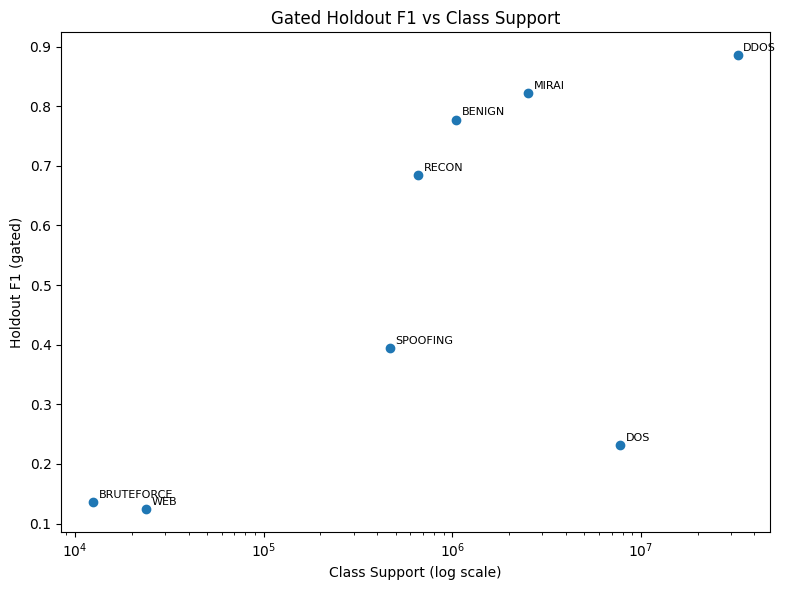

Validation vs holdout (RAW) per-class comparison:


,label,precision_val,recall_val,f1_val,support_val,precision_test,recall_test,f1_test,support_test,f1_gap
7,WEB,0.542654,0.537438,0.540033,5409.0,0.054037,0.445794,0.096391,23798,0.443643
4,MIRAI,0.980287,0.996137,0.988149,68343.0,0.703124,0.998035,0.825017,2521551,0.163132
6,SPOOFING,0.775684,0.259104,0.388452,8101.0,0.730073,0.235945,0.356633,465914,0.031819
5,RECON,0.655789,0.702800,0.678481,9751.0,0.621291,0.728026,0.670437,661108,0.008044
2,DDOS,0.811760,0.993312,0.893406,150868.0,0.823646,0.957983,0.885750,32535697,0.007656
0,BENIGN,0.589816,0.777280,0.670695,8926.0,0.787647,0.729722,0.757579,1051313,-0.086884
3,DOS,0.638506,0.060080,0.109826,36984.0,0.726379,0.137573,0.231333,7746340,-0.121507
1,BRUTEFORCE,0.000000,0.000000,0.000000,0.0,0.156815,0.426689,0.229343,12522,-0.229343


Validation vs holdout (GATED) per-class comparison:


,label,precision_val,recall_val,f1_val,support_val,precision_test,recall_test,f1_test,support_test,f1_gap
7,WEB,0.622222,0.408948,0.493530,5409.0,0.074407,0.368476,0.123812,23798,0.369717
4,MIRAI,0.976435,0.996152,0.986195,68343.0,0.698922,0.998038,0.822118,2521551,0.164077
6,SPOOFING,0.790116,0.303913,0.438977,8101.0,0.747191,0.268434,0.394971,465914,0.044005
5,RECON,0.770697,0.638704,0.698520,9751.0,0.702810,0.666861,0.684364,661108,0.014156
2,DDOS,0.811748,0.993319,0.893401,150868.0,0.823645,0.958007,0.885760,32535697,0.007642
0,BENIGN,0.531481,0.863433,0.657959,8926.0,0.754080,0.802236,0.777413,1051313,-0.119454
3,DOS,0.637956,0.060080,0.109818,36984.0,0.725986,0.137578,0.231320,7746340,-0.121502
1,BRUTEFORCE,0.000000,0.000000,0.000000,0.0,0.078992,0.475323,0.135471,12522,-0.135471


In [15]:
import matplotlib.pyplot as plt
import pandas as pd


def normalize_report_df(df):
    out = df.copy()
    if "label" not in out.columns:
        out = out.reset_index().rename(columns={"index": "label"})
    if "f1-score" in out.columns and "f1" not in out.columns:
        out = out.rename(columns={"f1-score": "f1"})

    required = ["label", "precision", "recall", "f1", "support"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        raise RuntimeError(f"Report is missing required columns: {missing}")

    out = out[out["label"].isin(class_names)].copy()
    return out[required]


val_raw_df = normalize_report_df(report_df_raw)
val_gated_df = normalize_report_df(report_df_gated)

test_raw_df = normalize_report_df(pd.read_csv(MODEL_DIR / "xgb_8class_test_per_class_raw.csv"))
test_gated_df = normalize_report_df(pd.read_csv(MODEL_DIR / "xgb_8class_test_per_class_gated.csv"))

val_raw_df.to_csv(MODEL_DIR / "xgb_8class_validation_per_class_raw.csv", index=False)
val_gated_df.to_csv(MODEL_DIR / "xgb_8class_validation_per_class_gated.csv", index=False)

print("Classes sorted by gated holdout F1:")
display(test_gated_df.sort_values("f1"))

print("Classes sorted by gated holdout support:")
display(test_gated_df.sort_values("support"))

plt.figure(figsize=(8, 6))
plt.scatter(test_gated_df["support"], test_gated_df["f1"])
for _, row in test_gated_df.iterrows():
    plt.annotate(str(row["label"]), (row["support"], row["f1"]), fontsize=8, xytext=(4, 3), textcoords="offset points")

plt.xscale("log")
plt.xlabel("Class Support (log scale)")
plt.ylabel("Holdout F1 (gated)")
plt.title("Gated Holdout F1 vs Class Support")
plt.tight_layout()
plt.show()

compare_raw_df = val_raw_df.merge(
    test_raw_df,
    on="label",
    suffixes=("_val", "_test"),
)
compare_raw_df["f1_gap"] = compare_raw_df["f1_val"] - compare_raw_df["f1_test"]
compare_raw_df = compare_raw_df.sort_values("f1_gap", ascending=False)

compare_gated_df = val_gated_df.merge(
    test_gated_df,
    on="label",
    suffixes=("_val", "_test"),
)
compare_gated_df["f1_gap"] = compare_gated_df["f1_val"] - compare_gated_df["f1_test"]
compare_gated_df = compare_gated_df.sort_values("f1_gap", ascending=False)

print("Validation vs holdout (RAW) per-class comparison:")
display(compare_raw_df)

print("Validation vs holdout (GATED) per-class comparison:")
display(compare_gated_df)

### Cell 16 -- Sanity Baseline A: Binary BENIGN vs MALICIOUS
This cell trains a binary baseline on the same file-aware split protocol.

Improvements in this revision:
- Adds a binary reference to determine whether errors are mostly due to multiclass granularity.

Expected inputs:
- `X_train`, `X_val`, label strings, and holdout iterator.

Expected outputs:
- Binary validation metrics and holdout metrics/artifacts.

Tweakable variables:
- Binary model type and regularization strength.

In [16]:
y_train_bin = (y_train_label != "BENIGN").to_numpy(dtype=np.int32)
y_val_bin = (y_val_label != "BENIGN").to_numpy(dtype=np.int32)

binary_model = LogisticRegression(
    max_iter=400,
    class_weight="balanced",
    solver="lbfgs",
)

binary_model.fit(X_train, y_train_bin)

val_bin_pred = binary_model.predict(X_val).astype(np.int32)
val_bin_acc = accuracy_score(y_val_bin, val_bin_pred)
val_bin_f1 = f1_score(y_val_bin, val_bin_pred, average="binary")

val_bin_report = pd.DataFrame(
    classification_report(
        y_val_bin,
        val_bin_pred,
        labels=[0, 1],
        target_names=["BENIGN", "MALICIOUS"],
        output_dict=True,
        zero_division=0,
    )
).T

bin_cm = np.zeros((2, 2), dtype=np.int64)
bin_seen_rows = 0
bin_dropped_rows = 0

for chunk in iter_test_chunks(
    test_files,
    base_feature_columns=BASE_FEATURE_COLUMNS,
    all_feature_columns=ALL_FEATURE_COLUMNS,
    chunksize=CHUNKSIZE,
    grouping_version=GROUPING_VERSION,
):
    valid = chunk["label_bin"].notna()
    bin_dropped_rows += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[ALL_FEATURE_COLUMNS].astype("float32")
    y_true_bin = (chunk["label_bin"] == "MALICIOUS").to_numpy(dtype=np.int32)
    y_pred_bin = binary_model.predict(X_chunk).astype(np.int32)

    np.add.at(bin_cm, (y_true_bin, y_pred_bin), 1)
    bin_seen_rows += len(chunk)

tn, fp = bin_cm[0, 0], bin_cm[0, 1]
fn, tp = bin_cm[1, 0], bin_cm[1, 1]
total = bin_cm.sum()

binary_test_acc = float((tp + tn) / total) if total > 0 else np.nan
binary_test_precision = float(tp / (tp + fp)) if (tp + fp) > 0 else np.nan
binary_test_recall = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
binary_test_f1 = (
    float(2 * binary_test_precision * binary_test_recall / (binary_test_precision + binary_test_recall))
    if (binary_test_precision + binary_test_recall) > 0
    else np.nan
)

binary_model_path = MODEL_DIR / "binary_benign_vs_malicious_logreg.joblib"
binary_metrics_path = MODEL_DIR / "binary_benign_vs_malicious_metrics.json"
binary_cm_path = MODEL_DIR / "binary_benign_vs_malicious_confusion_matrix.csv"
binary_val_report_path = MODEL_DIR / "binary_benign_vs_malicious_validation_report.csv"

joblib.dump(binary_model, binary_model_path)
val_bin_report.to_csv(binary_val_report_path)
pd.DataFrame(bin_cm, index=["BENIGN", "MALICIOUS"], columns=["BENIGN", "MALICIOUS"]).to_csv(binary_cm_path)

binary_metrics = {
    "validation": {
        "accuracy": float(val_bin_acc),
        "f1": float(val_bin_f1),
    },
    "holdout": {
        "accuracy": float(binary_test_acc),
        "precision": None if np.isnan(binary_test_precision) else float(binary_test_precision),
        "recall": None if np.isnan(binary_test_recall) else float(binary_test_recall),
        "f1": None if np.isnan(binary_test_f1) else float(binary_test_f1),
    },
    "evaluated_test_rows": int(bin_seen_rows),
    "dropped_test_rows": int(bin_dropped_rows),
}

with open(binary_metrics_path, "w") as f:
    json.dump(binary_metrics, f, indent=2)

print("Binary validation accuracy:", val_bin_acc)
print("Binary validation F1:", val_bin_f1)
print("Binary holdout accuracy:", binary_test_acc)
print("Binary holdout F1:", binary_test_f1)
print("Saved binary baseline artifacts.")

display(val_bin_report)

/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Binary validation accuracy: 0.9207960274913136
Binary validation F1: 0.9573918380214561
Binary holdout accuracy: 0.9742124098446046
Binary holdout F1: 0.986621344967676
Saved binary baseline artifacts.


,precision,recall,f1-score,support
BENIGN,0.280983,1.000000,0.438700,8926.000000
MALICIOUS,1.000000,0.918266,0.957392,279456.000000
accuracy,0.920796,0.920796,0.920796,0.920796
macro avg,0.640492,0.959133,0.698046,288382.000000
weighted avg,0.977745,0.920796,0.941337,288382.000000


### Cell 17 -- Sanity Baseline B: Random Forest Multiclass
This cell trains and evaluates a Random Forest multiclass baseline using the same split protocol.

Improvements in this revision:
- Adds model-family contrast against XGBoost to isolate split/data vs model effects.

Expected inputs:
- Same train/validation matrices and holdout iterator.

Expected outputs:
- RF validation/holdout metrics and saved artifacts.

Tweakable variables:
- `n_estimators`, `max_depth`, `min_samples_leaf`, and class weighting strategy.

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=24,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=8,
)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val).astype(np.int32)
rf_val_acc = accuracy_score(y_val, rf_val_pred)
rf_val_macro_f1 = f1_score(y_val, rf_val_pred, average="macro")
rf_val_weighted_f1 = f1_score(y_val, rf_val_pred, average="weighted")

rf_val_report_df = pd.DataFrame(
    classification_report(
        y_val,
        rf_val_pred,
        labels=list(range(len(class_names))),
        target_names=[id_to_label[i] for i in range(len(class_names))],
        output_dict=True,
        zero_division=0,
    )
).T

rf_cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
rf_seen_rows = 0
rf_dropped_rows = 0

for chunk in iter_test_chunks(
    test_files,
    base_feature_columns=BASE_FEATURE_COLUMNS,
    all_feature_columns=ALL_FEATURE_COLUMNS,
    chunksize=CHUNKSIZE,
    grouping_version=GROUPING_VERSION,
):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    rf_dropped_rows += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[ALL_FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)
    y_pred = rf_model.predict(X_chunk).astype(np.int32)

    np.add.at(rf_cm, (y_true, y_pred), 1)
    rf_seen_rows += len(chunk)

rf_test_acc, rf_test_macro_f1, rf_test_weighted_f1, rf_test_per_class = metrics_from_confusion_matrix(rf_cm)

rf_model_path = MODEL_DIR / "rf_8class_baseline.joblib"
rf_val_report_path = MODEL_DIR / "rf_8class_validation_per_class.csv"
rf_test_report_path = MODEL_DIR / "rf_8class_test_per_class.csv"
rf_test_cm_path = MODEL_DIR / "rf_8class_test_confusion_matrix.csv"
rf_metrics_path = MODEL_DIR / "rf_8class_test_metrics.json"

joblib.dump(rf_model, rf_model_path)
rf_val_report_df.to_csv(rf_val_report_path)
rf_test_per_class.to_csv(rf_test_report_path, index=False)
pd.DataFrame(
    rf_cm,
    index=[id_to_label[i] for i in range(len(class_names))],
    columns=[id_to_label[i] for i in range(len(class_names))],
).to_csv(rf_test_cm_path)

rf_metrics = {
    "validation": {
        "accuracy": float(rf_val_acc),
        "macro_f1": float(rf_val_macro_f1),
        "weighted_f1": float(rf_val_weighted_f1),
    },
    "holdout": {
        "accuracy": float(rf_test_acc),
        "macro_f1": float(rf_test_macro_f1),
        "weighted_f1": float(rf_test_weighted_f1),
    },
    "evaluated_test_rows": int(rf_seen_rows),
    "dropped_test_rows": int(rf_dropped_rows),
}

with open(rf_metrics_path, "w") as f:
    json.dump(rf_metrics, f, indent=2)

model_family_compare = pd.DataFrame({
    "model": ["xgb_gated", "random_forest"],
    "holdout_accuracy": [test_acc_gated, rf_test_acc],
    "holdout_macro_f1": [test_macro_f1_gated, rf_test_macro_f1],
    "holdout_weighted_f1": [test_weighted_f1_gated, rf_test_weighted_f1],
})

print("RF validation accuracy:", rf_val_acc)
print("RF validation macro F1:", rf_val_macro_f1)
print("RF holdout accuracy:", rf_test_acc)
print("RF holdout macro F1:", rf_test_macro_f1)
print("Saved RF baseline artifacts.")

display(model_family_compare)
display(rf_test_per_class.sort_values("support", ascending=False))

RF validation accuracy: 0.8436067438328329
RF validation macro F1: 0.5473971684587746
RF holdout accuracy: 0.7949049677482971
RF holdout macro F1: 0.5045588521938588
Saved RF baseline artifacts.


,model,holdout_accuracy,holdout_macro_f1,holdout_weighted_f1
0,xgb_gated,0.803581,0.506904,0.758406
1,random_forest,0.794905,0.504559,0.760617


,label,precision,recall,f1,support
2,DDOS,0.827190,0.939502,0.879776,32535697
3,DOS,0.578108,0.174500,0.268081,7746340
4,MIRAI,0.717476,0.999025,0.835160,2521551
0,BENIGN,0.833203,0.729305,0.777800,1051313
5,RECON,0.709120,0.665528,0.686633,661108
6,SPOOFING,0.638687,0.232800,0.341225,465914
7,WEB,0.057239,0.837886,0.107158,23798
1,BRUTEFORCE,0.075932,0.951286,0.140638,12522


### Cell 18 -- Visual Dashboards (Raw/Gated XGBoost vs RF + Summary)

This cell renders heatmaps and comparison plots for improved XGBoost and Random Forest baselines.

Improvements in this revision:
- Compares raw-vs-gated XGBoost and Random Forest in one place.
- Adds a compact metric summary table from saved JSON artifacts.

Expected inputs:
- Saved confusion matrices and per-class reports from earlier cells.

Expected outputs:
- Heatmaps, bar charts, and metric summary displays.

Tweakable variables:
- Which confusion matrices/reports are included in plots.

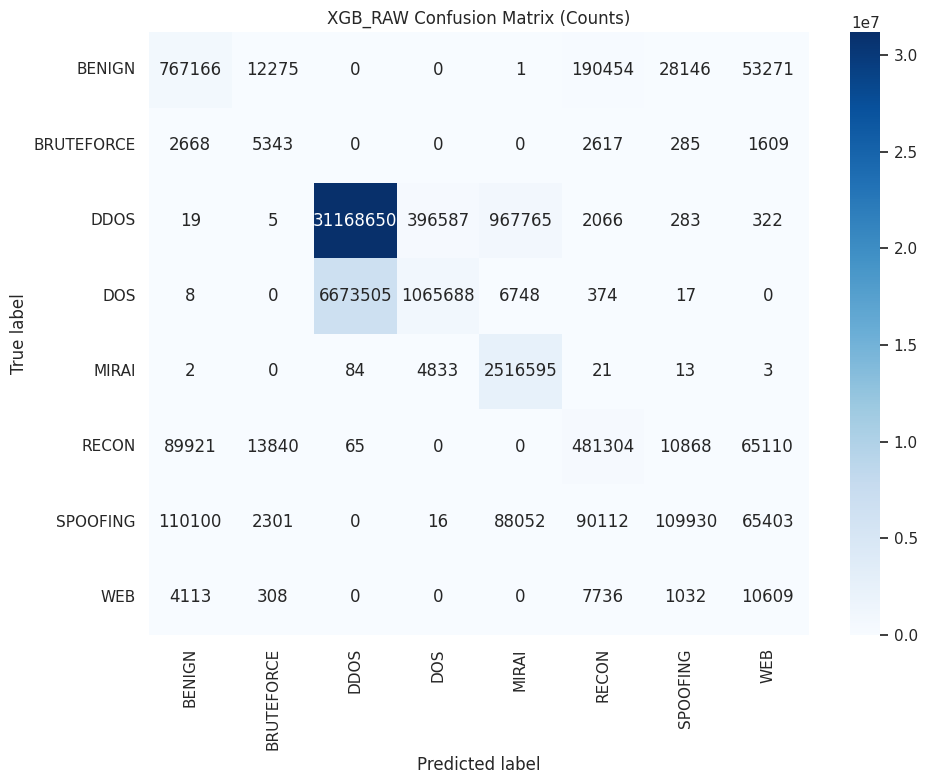

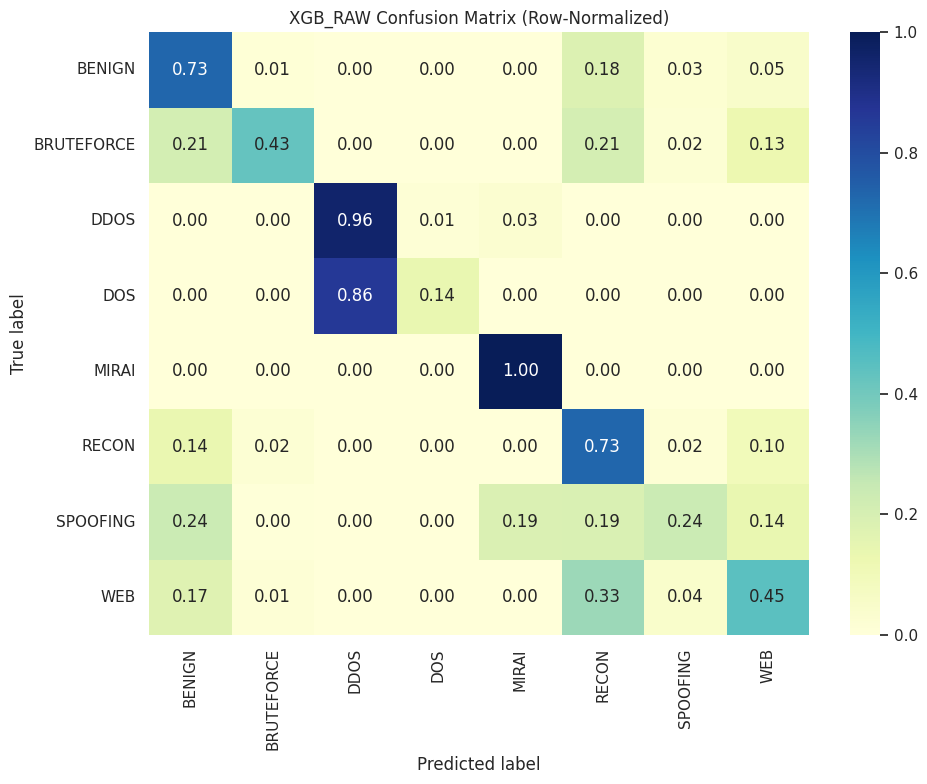

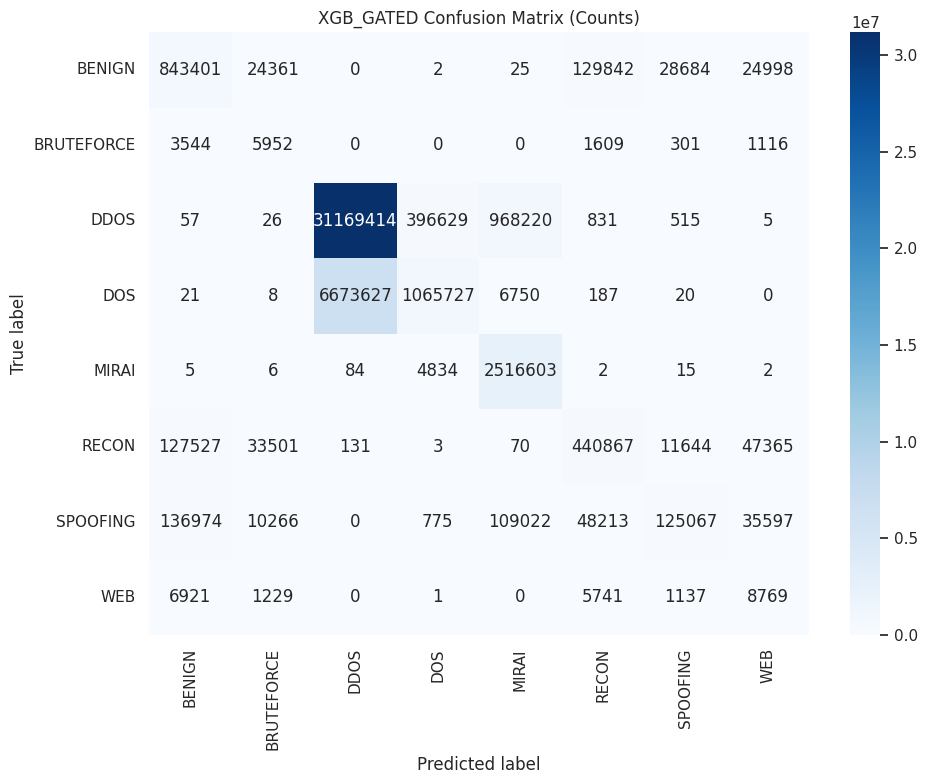

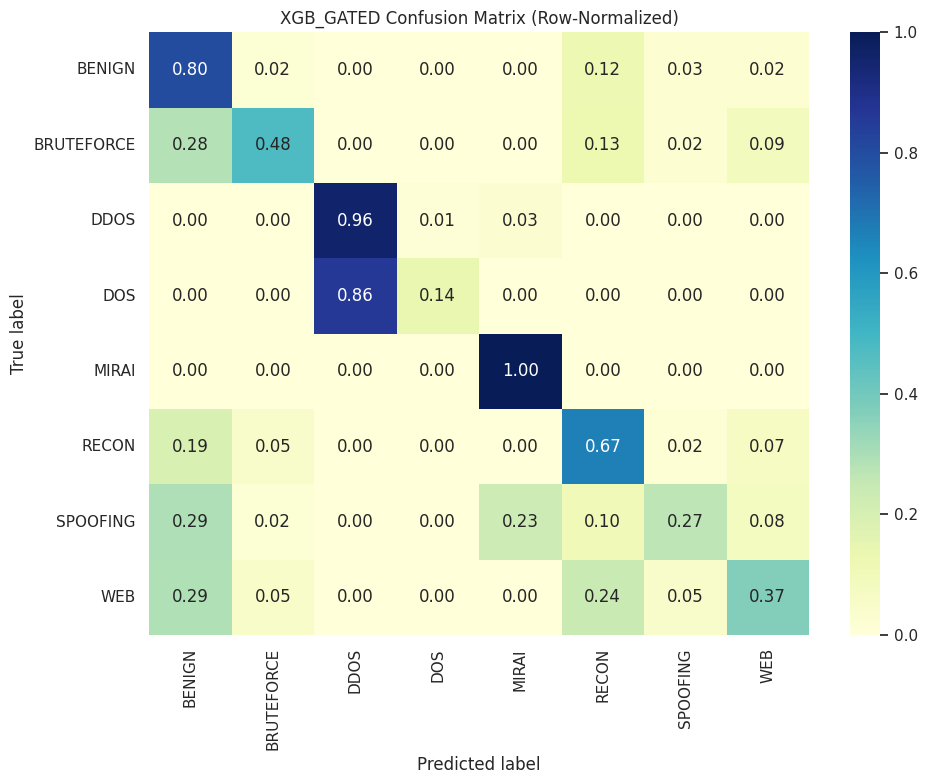

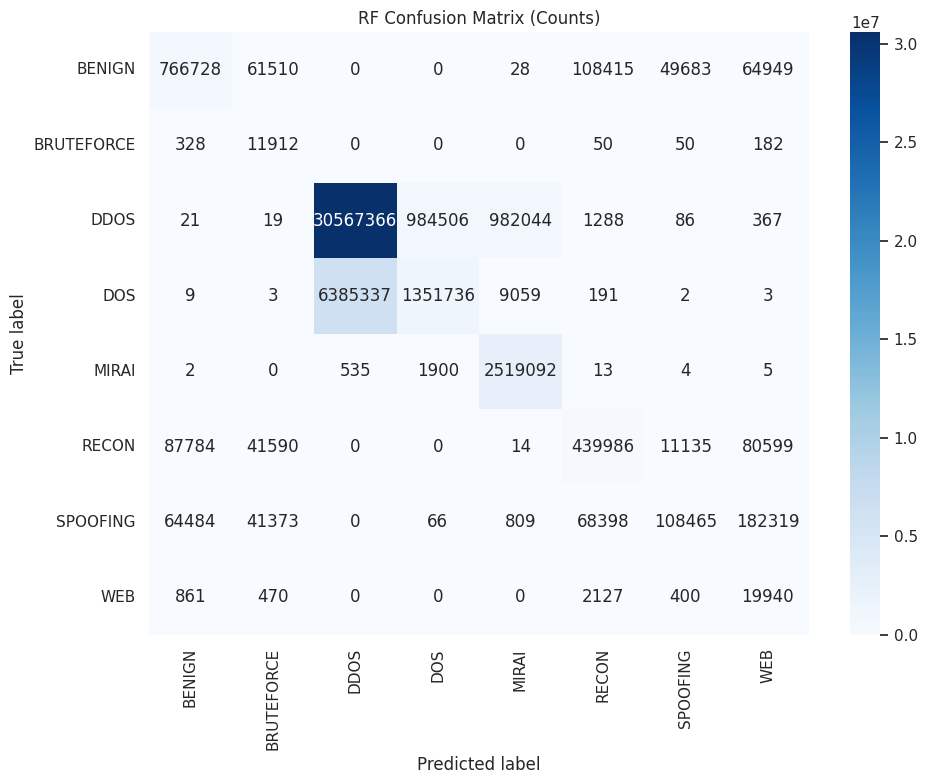

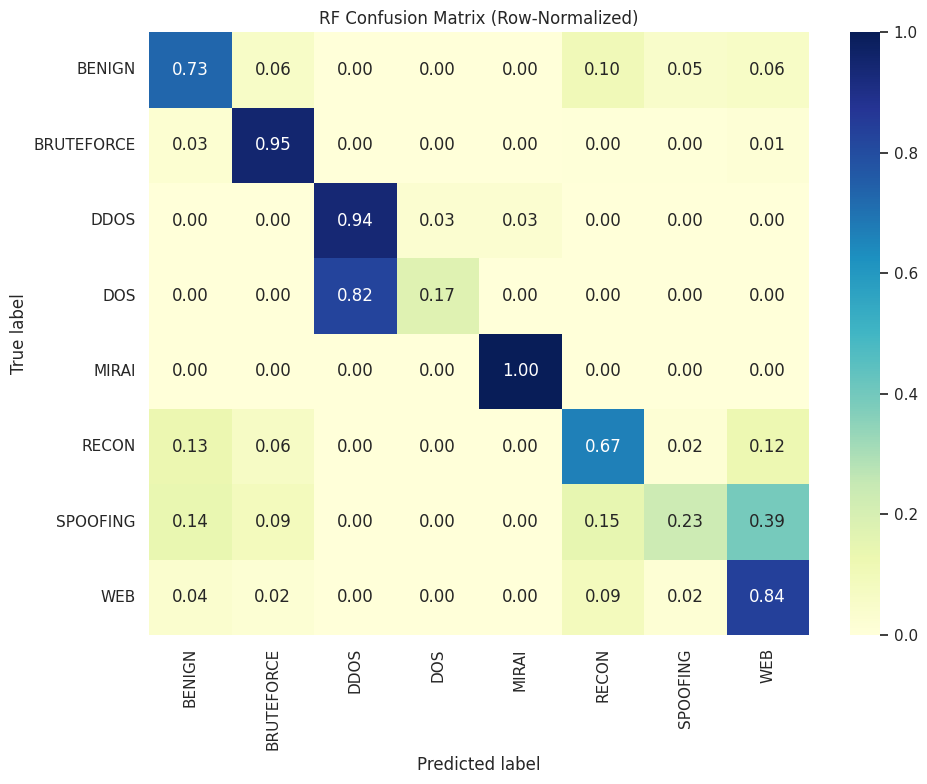

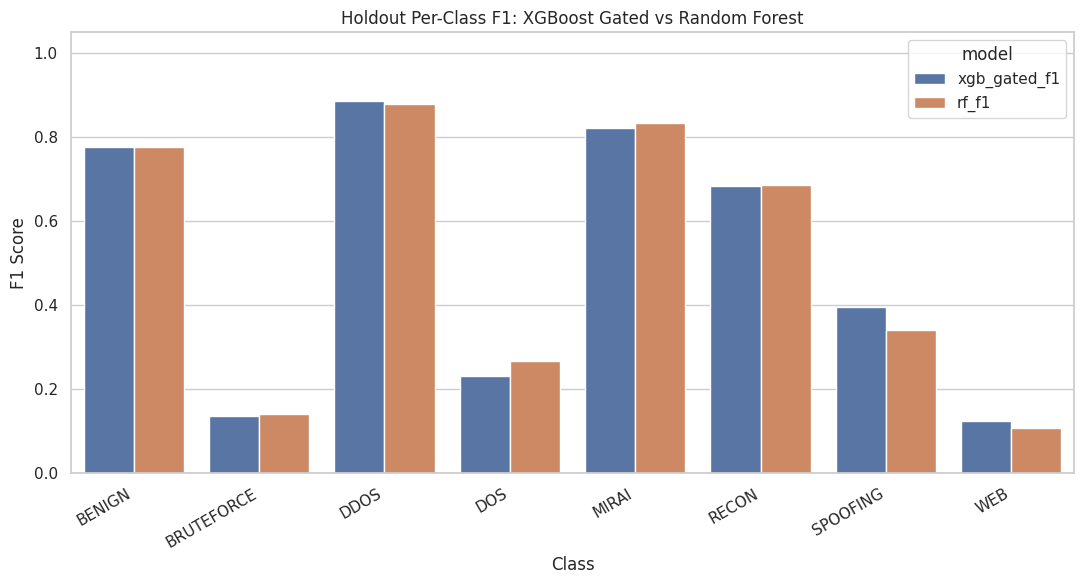

Model summary metrics:


,model,accuracy,macro_f1,weighted_f1
3,binary_benign_vs_malicious,0.974212,NaN,0.986621
1,xgb_gated,0.803581,0.506904,0.758406
0,xgb_raw,0.802459,0.506560,0.757511
2,random_forest,0.794905,0.504559,0.760617


Saved visual artifacts:
- artifacts/models/xgb_raw_counts_heatmap.png
- artifacts/models/xgb_raw_row_normalized_heatmap.png
- artifacts/models/xgb_gated_counts_heatmap.png
- artifacts/models/xgb_gated_row_normalized_heatmap.png
- artifacts/models/rf_counts_heatmap.png
- artifacts/models/rf_row_normalized_heatmap.png
- artifacts/models/holdout_f1_xgb_gated_vs_rf.png


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

labels = [id_to_label[i] for i in range(len(class_names))]

cm_paths = {
    "xgb_raw": MODEL_DIR / "xgb_8class_test_confusion_matrix_raw.csv",
    "xgb_gated": MODEL_DIR / "xgb_8class_test_confusion_matrix_gated.csv",
    "rf": MODEL_DIR / "rf_8class_test_confusion_matrix.csv",
}


def load_cm(path, labels_list):
    df = pd.read_csv(path, index_col=0)
    df = df.reindex(index=labels_list, columns=labels_list, fill_value=0)
    return df.to_numpy(dtype=np.int64)


def row_normalize(matrix):
    row_sums = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums != 0)


saved_pngs = []

for name, path in cm_paths.items():
    if not path.exists():
        print(f"Skipping missing confusion matrix: {path}")
        continue

    matrix = load_cm(path, labels)
    cm_df_local = pd.DataFrame(matrix, index=labels, columns=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df_local, annot=True, fmt=".0f", cmap="Blues", cbar=True)
    plt.title(f"{name.upper()} Confusion Matrix (Counts)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    counts_png = MODEL_DIR / f"{name}_counts_heatmap.png"
    plt.savefig(counts_png, dpi=200)
    plt.show()
    saved_pngs.append(counts_png)

    norm_matrix = row_normalize(matrix)
    norm_df = pd.DataFrame(norm_matrix, index=labels, columns=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(norm_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.0, vmax=1.0, cbar=True)
    plt.title(f"{name.upper()} Confusion Matrix (Row-Normalized)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    norm_png = MODEL_DIR / f"{name}_row_normalized_heatmap.png"
    plt.savefig(norm_png, dpi=200)
    plt.show()
    saved_pngs.append(norm_png)

xgb_gated_path = MODEL_DIR / "xgb_8class_test_per_class_gated.csv"
rf_path = MODEL_DIR / "rf_8class_test_per_class.csv"

if xgb_gated_path.exists() and rf_path.exists():
    xgb_df = pd.read_csv(xgb_gated_path)[["label", "f1"]].rename(columns={"f1": "xgb_gated_f1"})
    rf_df = pd.read_csv(rf_path)[["label", "f1"]].rename(columns={"f1": "rf_f1"})
    f1_compare = xgb_df.merge(rf_df, on="label", how="inner")
    f1_compare_long = f1_compare.melt(
        id_vars=["label"],
        value_vars=["xgb_gated_f1", "rf_f1"],
        var_name="model",
        value_name="f1",
    )

    plt.figure(figsize=(11, 6))
    sns.barplot(data=f1_compare_long, x="label", y="f1", hue="model")
    plt.ylim(0, 1.05)
    plt.title("Holdout Per-Class F1: XGBoost Gated vs Random Forest")
    plt.xlabel("Class")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    f1_compare_png = MODEL_DIR / "holdout_f1_xgb_gated_vs_rf.png"
    plt.savefig(f1_compare_png, dpi=200)
    plt.show()
    saved_pngs.append(f1_compare_png)
else:
    print("Skipping F1 comparison plot because one or more report files are missing.")

summary_rows = []

xgb_metrics_path = MODEL_DIR / "xgb_8class_test_metrics.json"
if xgb_metrics_path.exists():
    with open(xgb_metrics_path, "r") as f:
        xgb_metrics = json.load(f)
    summary_rows.append({
        "model": "xgb_raw",
        "accuracy": xgb_metrics["raw"]["accuracy"],
        "macro_f1": xgb_metrics["raw"]["macro_f1"],
        "weighted_f1": xgb_metrics["raw"]["weighted_f1"],
    })
    summary_rows.append({
        "model": "xgb_gated",
        "accuracy": xgb_metrics["gated"]["accuracy"],
        "macro_f1": xgb_metrics["gated"]["macro_f1"],
        "weighted_f1": xgb_metrics["gated"]["weighted_f1"],
    })

rf_metrics_path = MODEL_DIR / "rf_8class_test_metrics.json"
if rf_metrics_path.exists():
    with open(rf_metrics_path, "r") as f:
        rf_metrics = json.load(f)
    summary_rows.append({
        "model": "random_forest",
        "accuracy": rf_metrics["holdout"]["accuracy"],
        "macro_f1": rf_metrics["holdout"]["macro_f1"],
        "weighted_f1": rf_metrics["holdout"]["weighted_f1"],
    })

binary_metrics_path = MODEL_DIR / "binary_benign_vs_malicious_metrics.json"
if binary_metrics_path.exists():
    with open(binary_metrics_path, "r") as f:
        binary_metrics = json.load(f)
    summary_rows.append({
        "model": "binary_benign_vs_malicious",
        "accuracy": binary_metrics["holdout"]["accuracy"],
        "macro_f1": np.nan,
        "weighted_f1": binary_metrics["holdout"]["f1"],
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("Model summary metrics:")
    display(summary_df.sort_values("accuracy", ascending=False))
else:
    print("No summary metric files found.")

print("Saved visual artifacts:")
for path in saved_pngs:
    print("-", path)